# Introduction to ggplot2_py

ggplot2_py is a Python port of the R ggplot2 package for producing visualizations of data.
Unlike many graphics packages, ggplot2_py uses a conceptual framework based on the
**grammar of graphics**. This allows you to compose a graph from individual elements --
data, aesthetic mappings, geometric objects, scales, facets, coordinates, and themes --
instead of being limited to a predefined set of chart types.

In this tutorial we walk through the seven composable parts that come together as a set
of instructions on how to draw a chart:

1. **Data** -- the foundation of every graphic
2. **Mapping** -- how variables in the data map to visual properties
3. **Layers** -- geometry, statistical transformations, and position adjustments
4. **Scales** -- control how data values translate to visual properties
5. **Facets** -- split the data into small multiples
6. **Coordinates** -- interpret position aesthetics (Cartesian, polar, etc.)
7. **Theme** -- control the non-data appearance of the plot

By the end of this tutorial you will be able to build a richly customized plot like this:

In [1]:
from ggplot2_py import *
from ggplot2_py.datasets import mpg, diamonds
import matplotlib as mpl

In [2]:
from ggplot2_py import GGPlot
GGPlot.fig_width = 5
GGPlot.fig_height = 3

In [3]:
%matplotlib inline

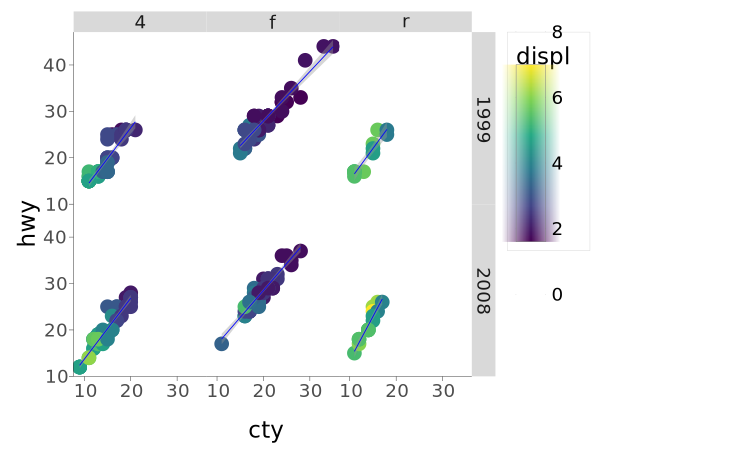

In [4]:
# A preview of what we will build by the end of this tutorial
gplot = (
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point(aes(colour="displ"))
    + geom_smooth(method="lm", linewidth=0.3)
    + scale_colour_viridis_c()
    + facet_grid("year", "drv")
    + coord_fixed()
    + theme_minimal()
    + theme(panel_grid_minor=element_blank())
)
gplot.fig_dpi = 100
gplot

In [5]:
# # Save to PNG
# ggsave("test.png", plot=gplot, width=8, height=5, dpi=150)

# # Save to PDF
# ggsave("test.pdf", plot=gplot, width=8, height=5)
# gplot

## 1. Data

As the foundation of every graphic, ggplot2_py uses tabular data (a pandas DataFrame)
to construct a plot. The system works best when the data is in a **tidy** format: a
rectangular DataFrame where each row is an observation and each column is a variable.

As the first step in many plots, you pass the data to the `ggplot()` function, which
stores it for use by subsequent layers. Let us start with the `mpg` dataset, which
contains fuel economy data for 38 popular car models from 1999 to 2008.

In [6]:
# Inspect the mpg dataset
print(mpg.shape)
mpg.head(10)

(234, 11)


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
5,audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact
6,audi,a4,3.1,2008,6,auto(av),f,18,27,p,compact
7,audi,a4 quattro,1.8,1999,4,manual(m5),4,18,26,p,compact
8,audi,a4 quattro,1.8,1999,4,auto(l5),4,16,25,p,compact
9,audi,a4 quattro,2.0,2008,4,manual(m6),4,20,28,p,compact


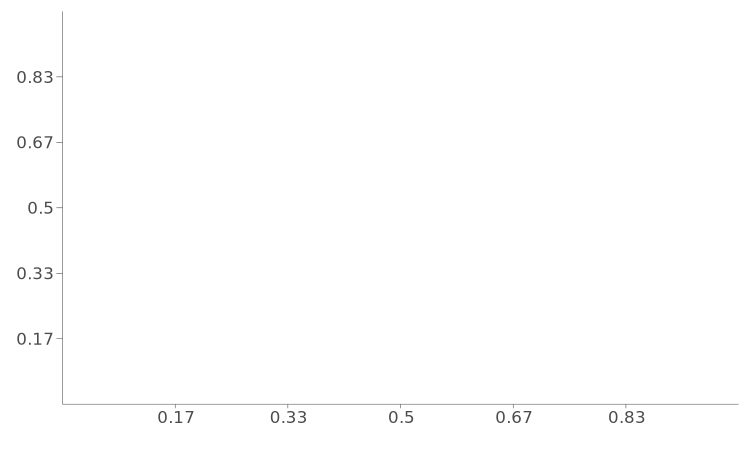

In [7]:
# Pass data to ggplot -- this creates an empty plot canvas
ggplot(data=mpg)

## 2. Mapping

A **mapping** is a set of instructions describing how columns in the data correspond
to aesthetic attributes of geometric objects. Think of it as a dictionary that
translates tidy data into the graphics system.

Mappings are created with the `aes()` function, which pairs graphical attributes
(like x-position, y-position, colour) with column names from the data.

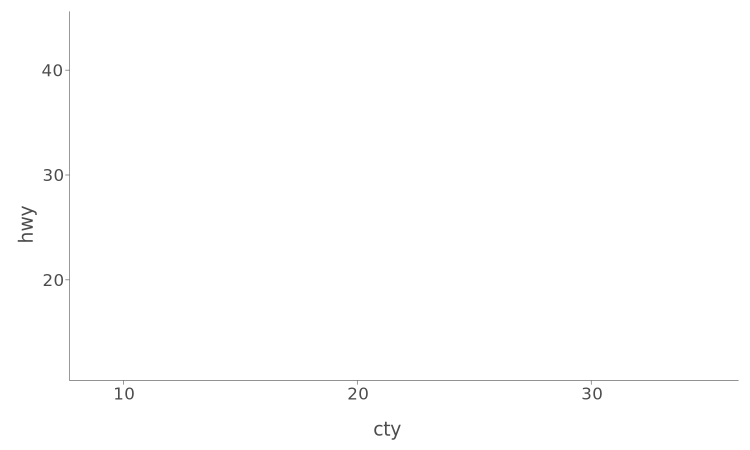

In [8]:
# Map the cty column to the x-axis and hwy to the y-axis
ggplot(mpg, aes(x="cty", y="hwy"))

Notice that we now have labelled axes, but no data is shown yet. We need to add a
**layer** to actually render the data.

## 3. Layers

The heart of any graphic is its **layers**. Each layer takes the mapped data and
displays it in a form humans can interpret. Every layer has three important parts:

- **Geometry** -- determines *how* data are displayed (points, lines, bars, etc.)
- **Statistical transformation** -- may compute new variables from the data,
  affecting *what* is displayed
- **Position adjustment** -- determines *where* a piece of data is placed

Layers are added with `geom_*()` or `stat_*()` functions.

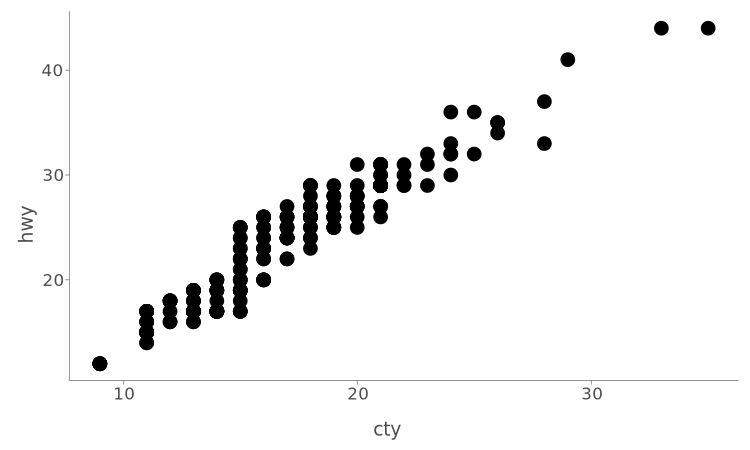

In [9]:
# A basic scatterplot using geom_point
ggplot(mpg, aes("cty", "hwy")) + geom_point()

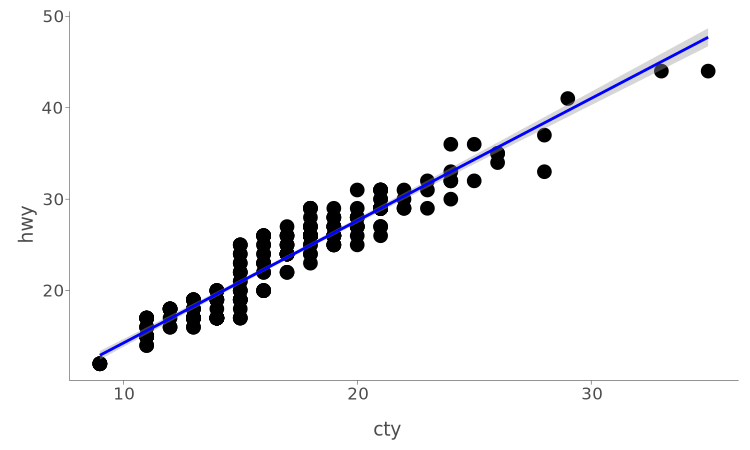

In [10]:
# Stack a linear trend line on top of the scatterplot
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    + geom_smooth(method="lm")
)

### 3a. Adding aesthetics: colour, size, shape

You can map additional variables to aesthetic properties like colour, size, and shape.
When these are placed inside `aes()`, ggplot2_py automatically creates a legend.

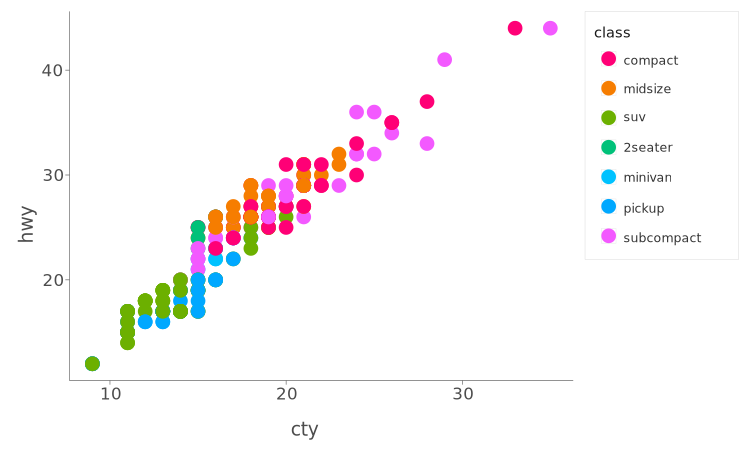

In [11]:
# Map the 'class' variable to colour
ggplot(mpg, aes("cty", "hwy", colour="class")) + geom_point()

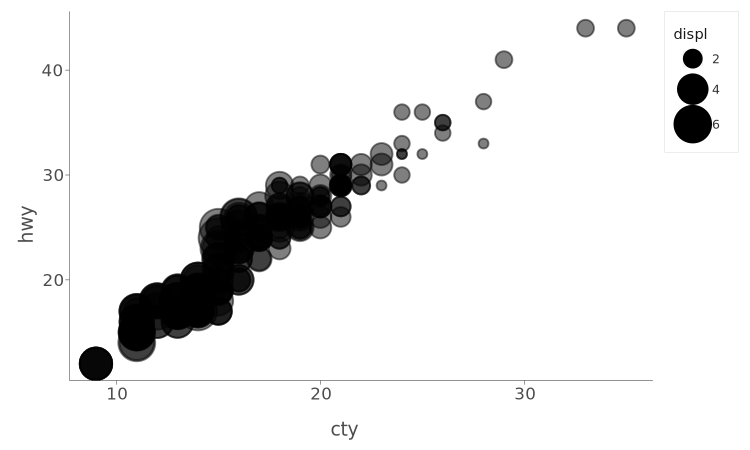

In [12]:
# Map 'displ' (engine displacement) to size
ggplot(mpg, aes("cty", "hwy", size="displ")) + geom_point(alpha=0.5)

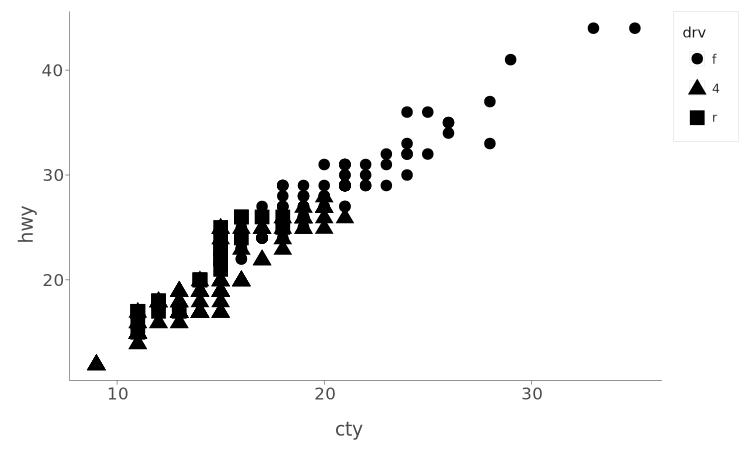

In [13]:
# Map 'drv' (drive train) to shape
ggplot(mpg, aes("cty", "hwy", shape="drv")) + geom_point()

### 3b. Statistical transformations

Some geoms perform statistical transformations on the data before plotting.
For example, `geom_bar()` counts the number of observations in each group,
and `geom_histogram()` bins continuous data.

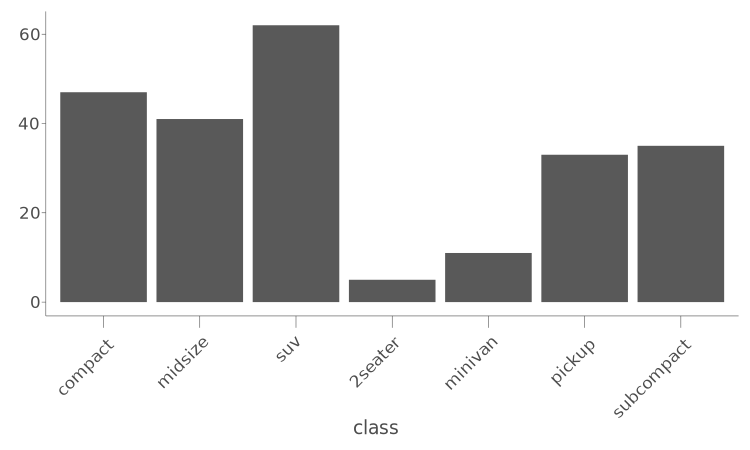

In [14]:
# geom_bar counts observations per category by default
ggplot(mpg, aes(x="class")) + geom_bar() + theme(axis_text_x=element_text(angle=45, hjust=1)) 

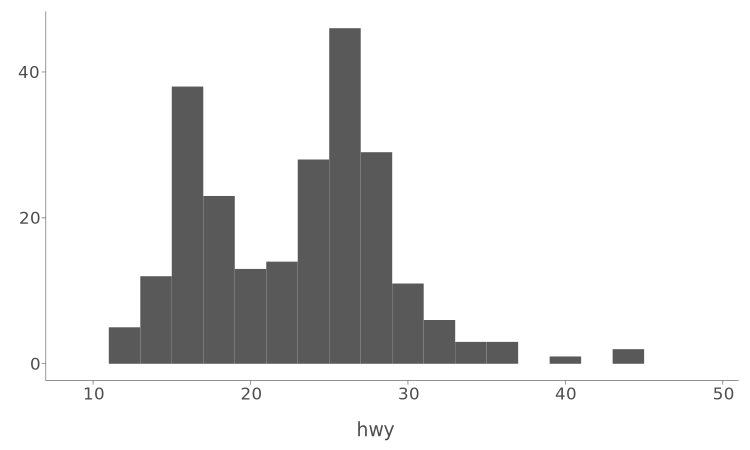

In [15]:
# geom_histogram bins a continuous variable
ggplot(mpg, aes(x="hwy")) + geom_histogram(binwidth=2)

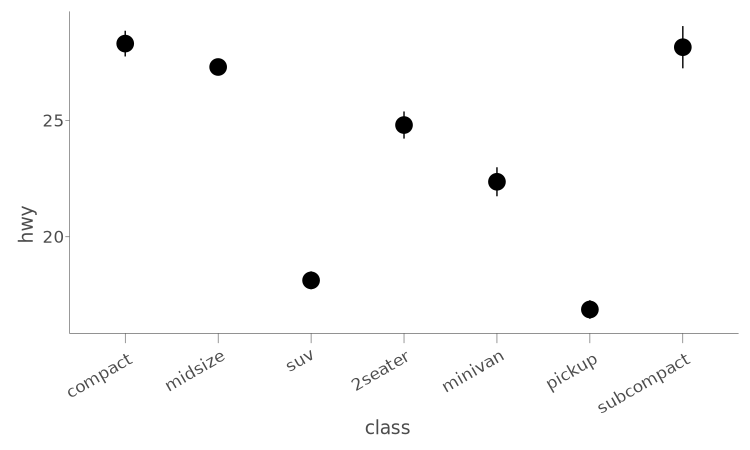

In [16]:
# stat_summary computes summary statistics (here, mean and standard error)
ggplot(mpg, aes("class", "hwy")) + stat_summary(fun_data="mean_se")

### 3c. Position adjustments

Position adjustments control where overlapping geoms are placed. Common options
include `position_dodge()` (side-by-side), `position_fill()` (stacked to 100%),
and `position_jitter()` (random noise to reduce overplotting).

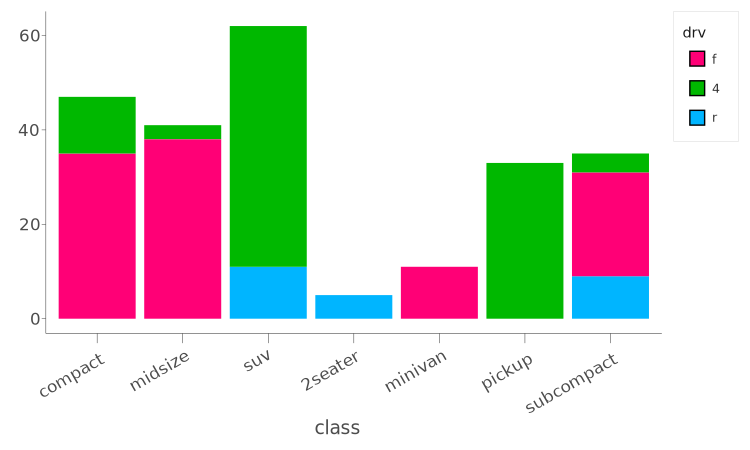

In [17]:
# Stacked bar chart -- the default for geom_bar with a fill aesthetic
ggplot(mpg, aes(x="class", fill="drv")) + geom_bar()

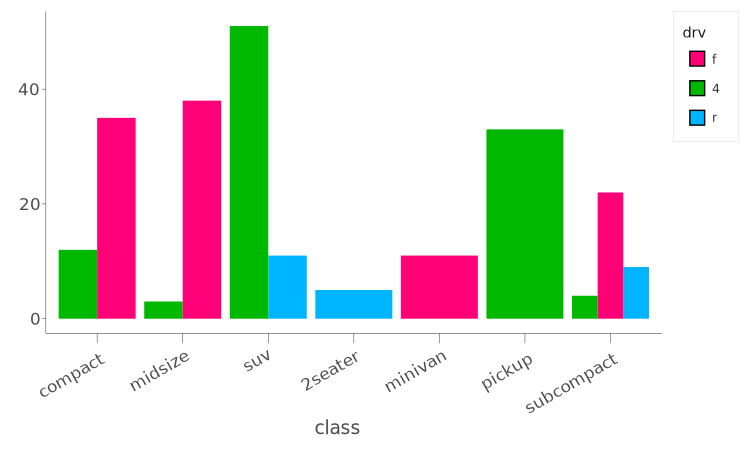

In [18]:
# Dodged bar chart -- bars placed side-by-side
ggplot(mpg, aes(x="class", fill="drv")) + geom_bar(position="dodge")

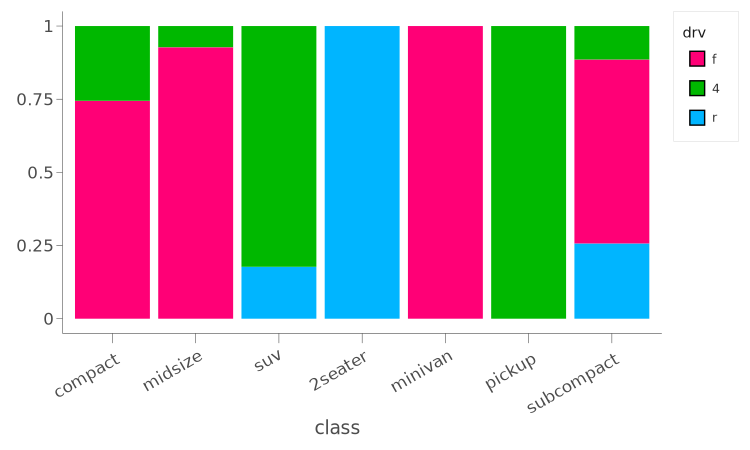

In [19]:
# Proportional stacked bar chart
ggplot(mpg, aes(x="class", fill="drv")) + geom_bar(position="fill")

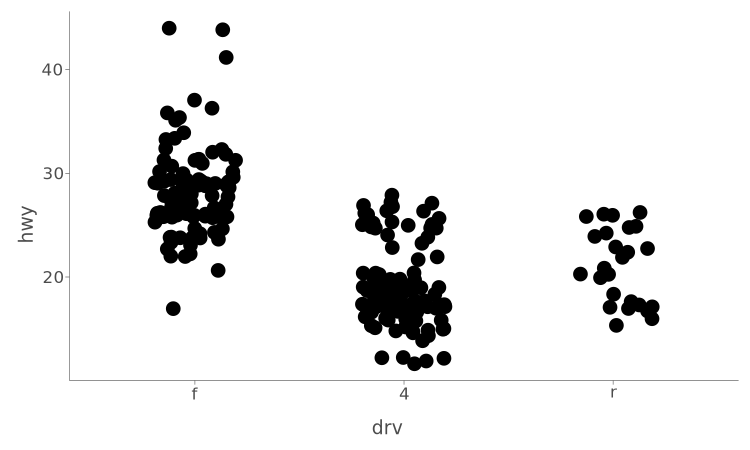

In [20]:
# Jittering to reduce overplotting in a scatterplot
ggplot(mpg, aes("drv", "hwy")) + geom_jitter(width=0.2)

## 4. Scales

**Scales** translate what is shown on the graph back to an understanding of the data.
They form pairs with aesthetic attributes and are represented by guides (axes and
legends). Scales control the limits, breaks, labels, and optional transformations.

Scale functions follow the naming pattern `scale_{aesthetic}_{type}()`.

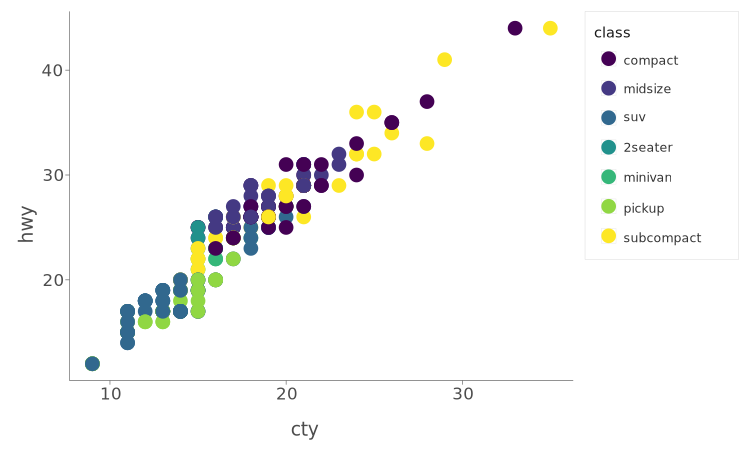

In [21]:
# Use the viridis discrete palette for the 'class' colour mapping
(
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + scale_colour_viridis_d()
)

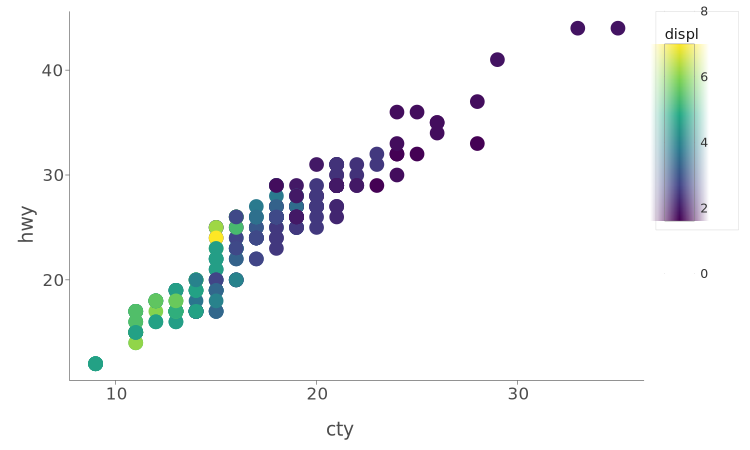

In [22]:
# Continuous colour mapping with viridis
(
    ggplot(mpg, aes("cty", "hwy", colour="displ"))
    + geom_point()
    + scale_colour_viridis_c()
)

## 5. Facets

**Facets** split the data into small multiples -- separate panels for subsets of
the data based on one or more variables. This is a powerful way to explore patterns
across different groups.

- `facet_wrap()` wraps a one-dimensional sequence of panels into a 2D layout
- `facet_grid()` forms a matrix of panels defined by row and column variables

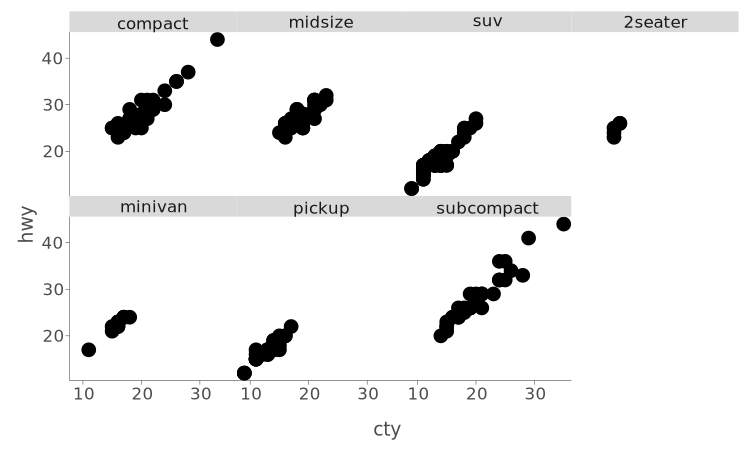

In [23]:
# facet_wrap: one variable, wrapped into rows
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    + facet_wrap("class", ncol=4)
)

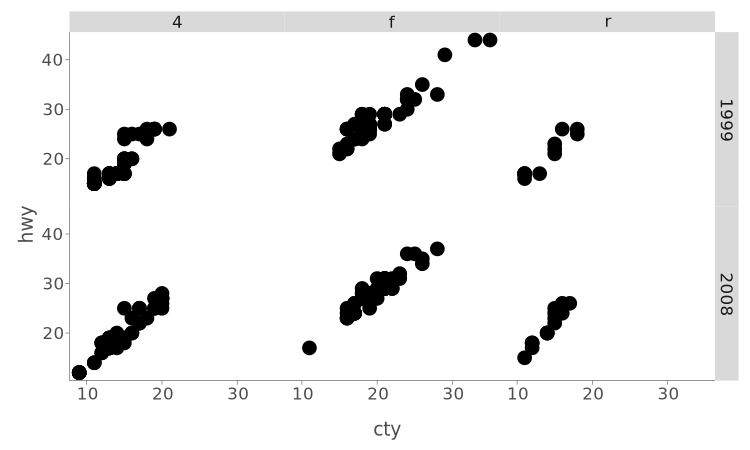

In [24]:
# facet_grid: two variables forming a row-by-column matrix
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    + facet_grid("year", "drv")
)

## 6. Coordinates

The **coordinate system** interprets position aesthetics. While Cartesian coordinates
are the default, ggplot2_py also supports fixed-ratio coordinates, flipped coordinates,
and polar coordinates.

- `coord_fixed()` / `coord_equal()` -- fixed aspect ratio (1 unit on x = 1 unit on y)
- `coord_flip()` -- swap x and y axes
- `coord_polar()` -- polar coordinates (useful for pie charts and wind roses)

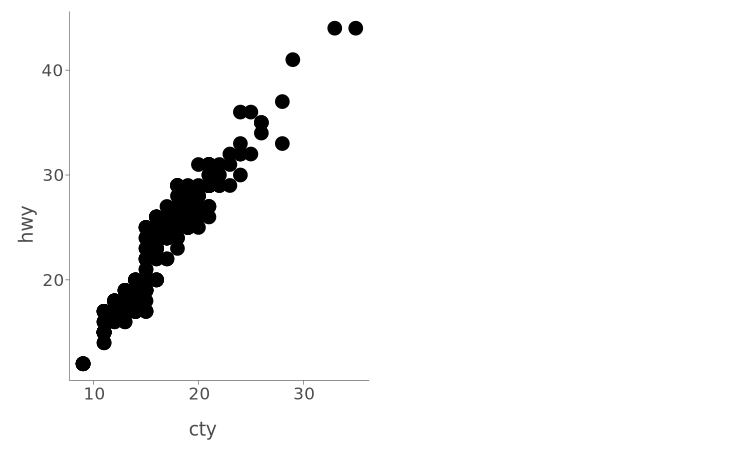

In [25]:
# Fixed aspect ratio so one mile per gallon has the same length on both axes
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    + coord_fixed()
)

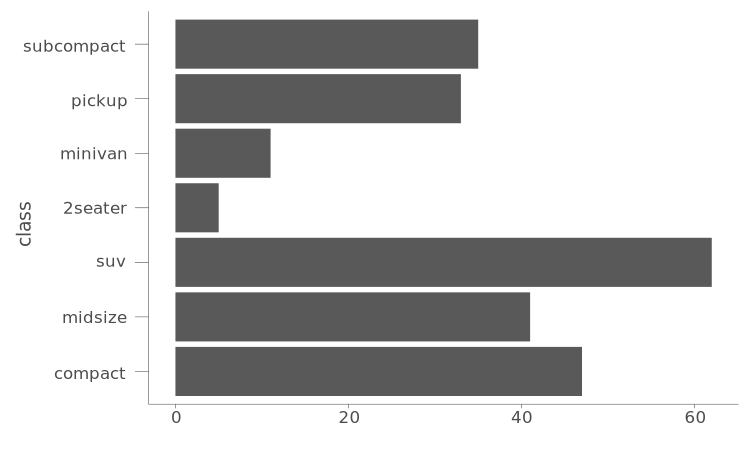

In [26]:
# Flip coordinates to make a horizontal bar chart
(
    ggplot(mpg, aes(x="class"))
    + geom_bar()
    + coord_flip()
)

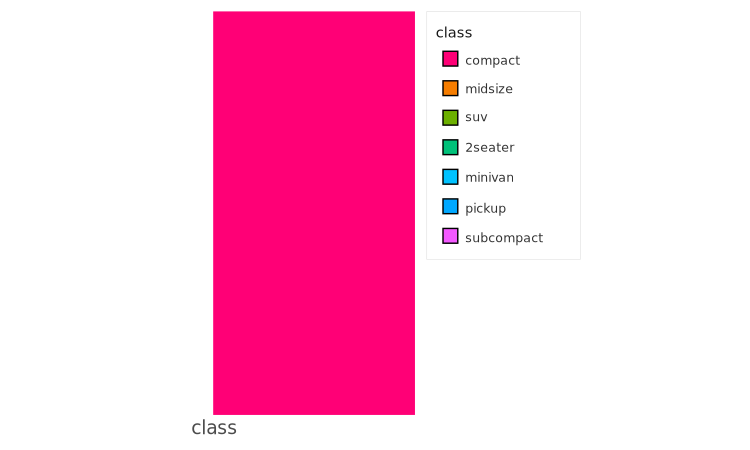

In [27]:
# Polar coordinates -- a bar chart transformed into a Coxcomb / rose plot
(
    ggplot(mpg, aes(x="class", fill="class"))
    + geom_bar(width=1)
    + coord_polar()
)

## 7. Theme

The **theme** system controls almost every visual aspect of the plot that is not
determined by the data: background colours, grid lines, font sizes, legend
placement, and more.

ggplot2_py ships with several built-in themes (`theme_grey()`, `theme_bw()`,
`theme_minimal()`, `theme_classic()`, `theme_void()`, etc.), and you can further
customise any element with the `theme()` function and `element_*()` helpers.

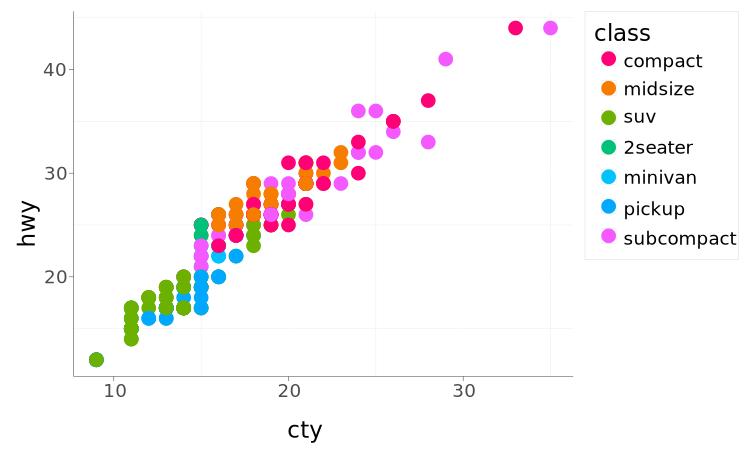

In [28]:
# Apply the minimal theme
(
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + theme_minimal()
)

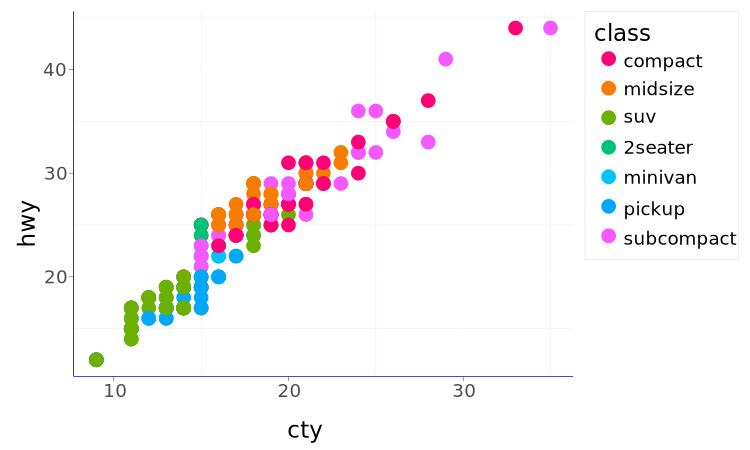

In [29]:
# Fine-tune individual theme elements
(
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + theme_minimal()
    + theme(
        legend_position="top",
        axis_line=element_line(linewidth=0.75),
        axis_line_x_bottom=element_line(colour="blue"),
    )
)

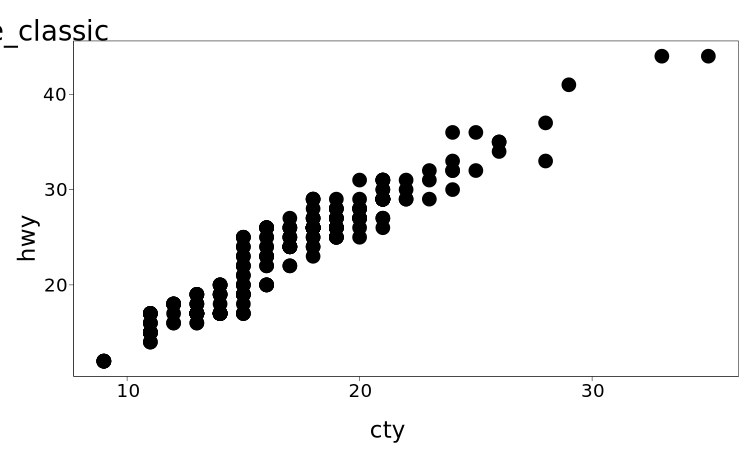

In [30]:
# Try several built-in themes side by side
base = ggplot(mpg, aes("cty", "hwy")) + geom_point()

# Classic theme (no grid, axis lines only)
base + theme_classic() + ggtitle("theme_classic")

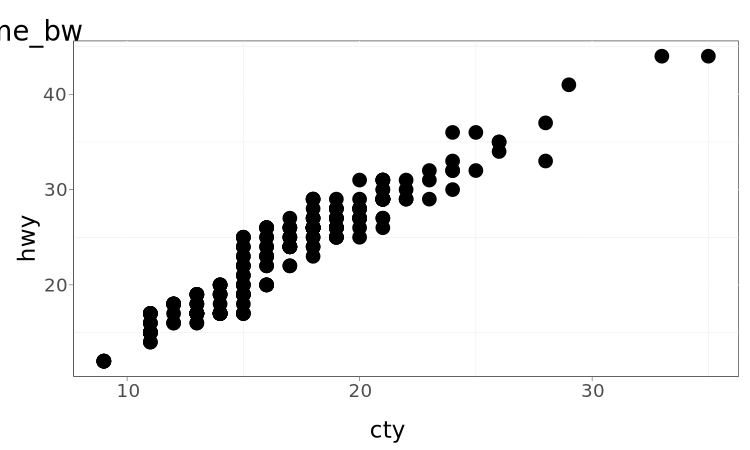

In [31]:
# Black-and-white theme
base + theme_bw() + ggtitle("theme_bw")

## 8. Labels and titles

Clear labels help readers understand the plot. Use `labs()` to set the title,
subtitle, axis labels, caption, and legend titles all at once.

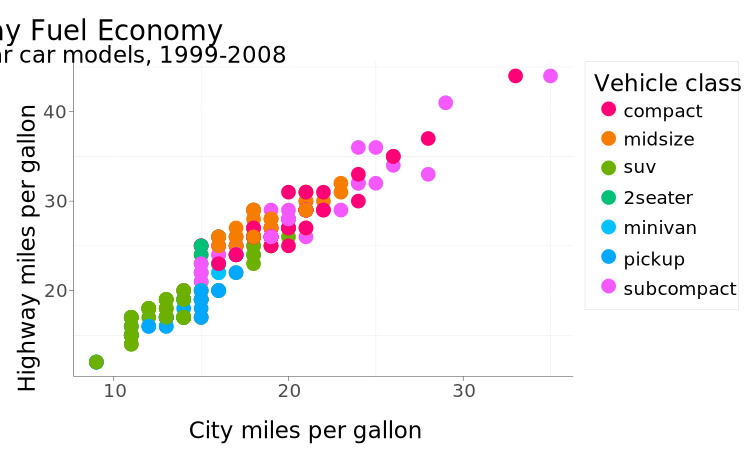

In [32]:
(
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + labs(
        title="City vs Highway Fuel Economy",
        subtitle="EPA data for 38 popular car models, 1999-2008",
        x="City miles per gallon",
        y="Highway miles per gallon",
        colour="Vehicle class",
    )
    + theme_minimal()
)

## 9. Saving plots

Use `ggsave()` to save the last plot (or a specific plot object) to a file.
The file format is inferred from the extension. You can control the width,
height, and resolution.

In [33]:
p = (
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + theme_minimal()
)

# # Save to PNG
# ggsave("fuel_economy.png", plot=p, width=8, height=5, dpi=150)

# # Save to PDF
# ggsave("fuel_economy.pdf", plot=p, width=8, height=5)

## 10. Putting it all together

As shown at the beginning, you can combine all the composable parts to build a
richly customised plot. Here is the full example again, with comments explaining
each layer.

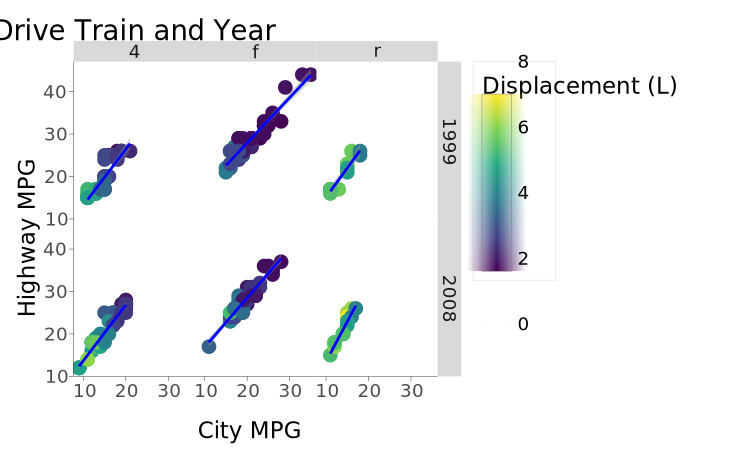

In [34]:
(
    ggplot(mpg, aes("cty", "hwy"))             # data + mapping
    + geom_point(aes(colour="displ"))            # layer 1: scatterplot coloured by displacement
    + geom_smooth(method="lm")                   # layer 2: linear trend line
    + scale_colour_viridis_c()                   # scale: viridis continuous palette
    + facet_grid("year", "drv")                  # facet: panels by year (rows) and drive train (cols)
    + coord_fixed()                              # coordinate: equal aspect ratio
    + theme_minimal()                            # theme: clean, minimal look
    + theme(panel_grid_minor=element_blank())    # theme tweak: remove minor grid lines
    + labs(
        title="Fuel Economy by Drive Train and Year",
        x="City MPG",
        y="Highway MPG",
        colour="Displacement (L)",
    )
)

## Next steps

This tutorial covered the core concepts of ggplot2_py. To learn more:

- Explore additional geoms: `geom_boxplot()`, `geom_violin()`, `geom_density()`,
  `geom_tile()`, `geom_hex()`, and many more.
- Try different scale functions to control colour palettes, axis transformations,
  and label formatting.
- Use `annotate()` and `annotation_custom()` to add custom annotations.